## Task 1: Processing Time Prediction - Performance Analysis


### 1. Setup and Imports

In [37]:
# Cell 1: Imports & settings
import os
import gc
import json
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing & modeling
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

import xgboost as xgb
import joblib

pd.set_option('display.max_columns', 200)
RNG_SEED = 42
np.random.seed(RNG_SEED)


### 2.  Load Datasets

In [38]:
# Provided files
BOOKINGS_FP = "bookings_train.csv"
TASKS_FP = "tasks.csv"
STAFFING_FP = "staffing_train.csv"

# Evaluation input for Task 1
#TASK1_TEST_INPUTS_FP = "task1_test_inputs.csv"

# Output artifacts
MODEL_FP = "task1_xgb_model.pkl"
SUBMISSION_TASK1_FP = "task1_submission.csv"

# Load
bookings = pd.read_csv(BOOKINGS_FP)
tasks = pd.read_csv(TASKS_FP)
staffing = pd.read_csv(STAFFING_FP)

print(bookings.head())
print(tasks.head())
print(staffing.head())


                                 booking_id  citizen_id booking_date  \
0  f7b59ba3793fea61282cb02be2247cebd0a75306  4229044420   2021-01-01   
1  cfe30d53b4b645e4cb6b114f6c9d74a0f25e6a80  5389442635   2021-01-01   
2  0fb0a5d9b3944dd743a9e7828dc03fa74aa6ebf8  2123783919   2021-01-01   
3  d4bf826153212fa325ad98b215668ab942365607  6359918966   2021-01-01   
4  ebb4c9687acbaf65376d8e379bd1341d1c15127e   178732202   2021-01-01   

  appointment_date appointment_time        check_in_time  \
0       2021-01-01            09:03  2021-01-01 09:11:00   
1       2021-01-01            09:12  2021-01-01 09:24:00   
2       2021-01-01            09:36  2021-01-01 09:29:00   
3       2021-01-01            09:45  2021-01-01 10:07:00   
4       2021-01-01            10:12  2021-01-01 10:26:00   

                  check_out_time   task_id  num_documents  queue_number  \
0  2021-01-01 09:48:15.166353269  TASK-002              0             2   
1  2021-01-01 10:24:12.189261137  TASK-001              

In [39]:
# Check for missing values in all columns
print("Missing values per column:")
missing_values = bookings.isnull().sum()
print(missing_values)

# Focus on check_in_time and check_out_time columns
print(f"\nSpecific missing values:")
print(f"Missing check_in_time: {bookings['check_in_time'].isnull().sum()}")
print(f"Missing check_out_time: {bookings['check_out_time'].isnull().sum()}")

# Check for empty strings as well
print(f"\nEmpty string values:")
print(f"Empty check_in_time: {(bookings['check_in_time'] == '').sum()}")
print(f"Empty check_out_time: {(bookings['check_out_time'] == '').sum()}")

# Total rows with missing or empty check_in_time OR check_out_time
rows_to_drop = bookings[(bookings['check_in_time'].isnull()) | (bookings['check_out_time'].isnull()) |
                  (bookings['check_in_time'] == '') | (bookings['check_out_time'] == '')]
print(f"\nTotal rows with missing or empty check_in_time OR check_out_time: {len(rows_to_drop)}")

Missing values per column:
booking_id                0
citizen_id                0
booking_date              0
appointment_date          0
appointment_time          0
check_in_time          6092
check_out_time         6092
task_id                   0
num_documents             0
queue_number              0
satisfaction_rating       0
dtype: int64

Specific missing values:
Missing check_in_time: 6092
Missing check_out_time: 6092

Empty string values:
Empty check_in_time: 0
Empty check_out_time: 0

Total rows with missing or empty check_in_time OR check_out_time: 6092


In [40]:
# Create a copy of the original dataframe
bookings_cleaned = bookings.copy()

# Replace empty strings with NaN for easier handling
bookings_cleaned['check_in_time'] = bookings_cleaned['check_in_time'].replace('', np.nan)
bookings_cleaned['check_out_time'] = bookings_cleaned['check_out_time'].replace('', np.nan)

# Drop rows where either check_in_time or check_out_time is NaN
bookings_cleaned = bookings_cleaned.dropna(subset=['check_in_time', 'check_out_time'])

print(f"Original dataset shape: {bookings.shape}")
print(f"Cleaned dataset shape: {bookings_cleaned.shape}")
print(f"Rows removed: {bookings.shape[0] - bookings_cleaned.shape[0]}")
print(f"Percentage of data retained: {(bookings_cleaned.shape[0] / bookings.shape[0]) * 100:.2f}%")

Original dataset shape: (203693, 11)
Cleaned dataset shape: (197601, 11)
Rows removed: 6092
Percentage of data retained: 97.01%


### 3. Basic Parsing and Target Computation

In [41]:
# Ensure datetime parsing
def parse_datetime_cols(df):
    # appointment_date/time
    df['appointment_date'] = pd.to_datetime(df['appointment_date'], errors='coerce')
    # appointment_time is time-only string (HH:MM:SS or HH:MM)
    # Create a combined datetime at appointment_date + appointment_time for potential features
    # First normalize appointment_time to HH:MM:SS
    def normalize_time(t):
        if pd.isna(t):
            return np.nan
        s = str(t)
        if len(s) == 5:  # HH:MM
            return s + ":00"
        return s
    df['appointment_time'] = df['appointment_time'].astype(str).apply(normalize_time)
    # df['appointment_time_parsed'] = pd.to_datetime(df['appointment_time'], format="%H:%M:%S", errors='coerce').dt.time

    # If needed, construct appointment_datetime for features
    # df['appointment_datetime'] = pd.to_datetime(
    #     df['appointment_date'].dt.strftime("%Y-%m-%d") + " " + df['appointment_time'].fillna("00:00:00"),
    #     errors='coerce'
    # )

    # check_in/out
    df['check_in_time'] = pd.to_datetime(df['check_in_time'], errors='coerce')
    df['check_out_time'] = pd.to_datetime(df['check_out_time'], errors='coerce')

    # Add number of appointments per task for that day (daily basis)
    # Count how many times each task appears on each day
    daily_task_counts = df.groupby(['appointment_date', 'task_id']).size().reset_index(name='appointments_per_task_daily')
    
    # Merge back to original dataframe to add the count for each row
    df = df.merge(daily_task_counts, on=['appointment_date', 'task_id'], how='left')
    
    return df

# Apply the function and get the modified dataframe back
bookings_cleaned = parse_datetime_cols(bookings_cleaned)

# Compute target: true_processing_time_minutes = (check_out - check_in).minutes
bookings_cleaned['processing_minutes'] = (bookings_cleaned['check_out_time'] - bookings_cleaned['check_in_time']).dt.total_seconds() / 60.0

# Filter training rows with valid target
train_df = bookings_cleaned.dropna(subset=['processing_minutes', 'appointment_date', 'task_id']).copy()
# Remove negative or impossible durations
train_df = train_df[train_df['processing_minutes'] >= 0]

print("Train rows after target filter:", len(train_df))
print(train_df.dtypes)
print(train_df.head(15))

Train rows after target filter: 197601
booking_id                             object
citizen_id                              int64
booking_date                           object
appointment_date               datetime64[ns]
appointment_time                       object
check_in_time                  datetime64[ns]
check_out_time                 datetime64[ns]
task_id                                object
num_documents                           int64
queue_number                            int64
satisfaction_rating                     int64
appointments_per_task_daily             int64
processing_minutes                    float64
dtype: object
                                  booking_id  citizen_id booking_date  \
0   f7b59ba3793fea61282cb02be2247cebd0a75306  4229044420   2021-01-01   
1   cfe30d53b4b645e4cb6b114f6c9d74a0f25e6a80  5389442635   2021-01-01   
2   0fb0a5d9b3944dd743a9e7828dc03fa74aa6ebf8  2123783919   2021-01-01   
3   d4bf826153212fa325ad98b215668ab942365607  6359918966 

### 4. Join tasks to get section_Id

In [42]:
train_df = train_df.merge(tasks[['task_id', 'section_id']], on='task_id', how='left')
# Keep only rows with valid mapping
train_df = train_df.dropna(subset=['section_id']).copy()

# converting to categorical datatype
for col in ['task_id', 'section_id']:
    train_df[col] = train_df[col].astype('category')

print(train_df[['task_id','section_id','appointment_date','appointment_time','processing_minutes']].head())

    task_id section_id appointment_date appointment_time  processing_minutes
0  TASK-002    SEC-001       2021-01-01         09:03:00           37.252773
1  TASK-001    SEC-001       2021-01-01         09:12:00           60.203154
2  TASK-002    SEC-001       2021-01-01         09:36:00           57.813371
3  TASK-001    SEC-001       2021-01-01         09:45:00           53.224761
4  TASK-002    SEC-001       2021-01-01         10:12:00           88.887670


### 5. EDA(Exploratory Data Analysis)

##### Target Variable Analysis


Descriptive Statistics:
count    197601.000000
mean         48.808690
std          24.001752
min           5.922487
10%          24.859472
25%          31.848814
50%          42.795068
75%          59.957378
90%          81.311931
95%          95.984507
99%         128.670626
max         217.635393
Name: processing_minutes, dtype: float64
Skewness: 1.455
Kurtosis: 2.943


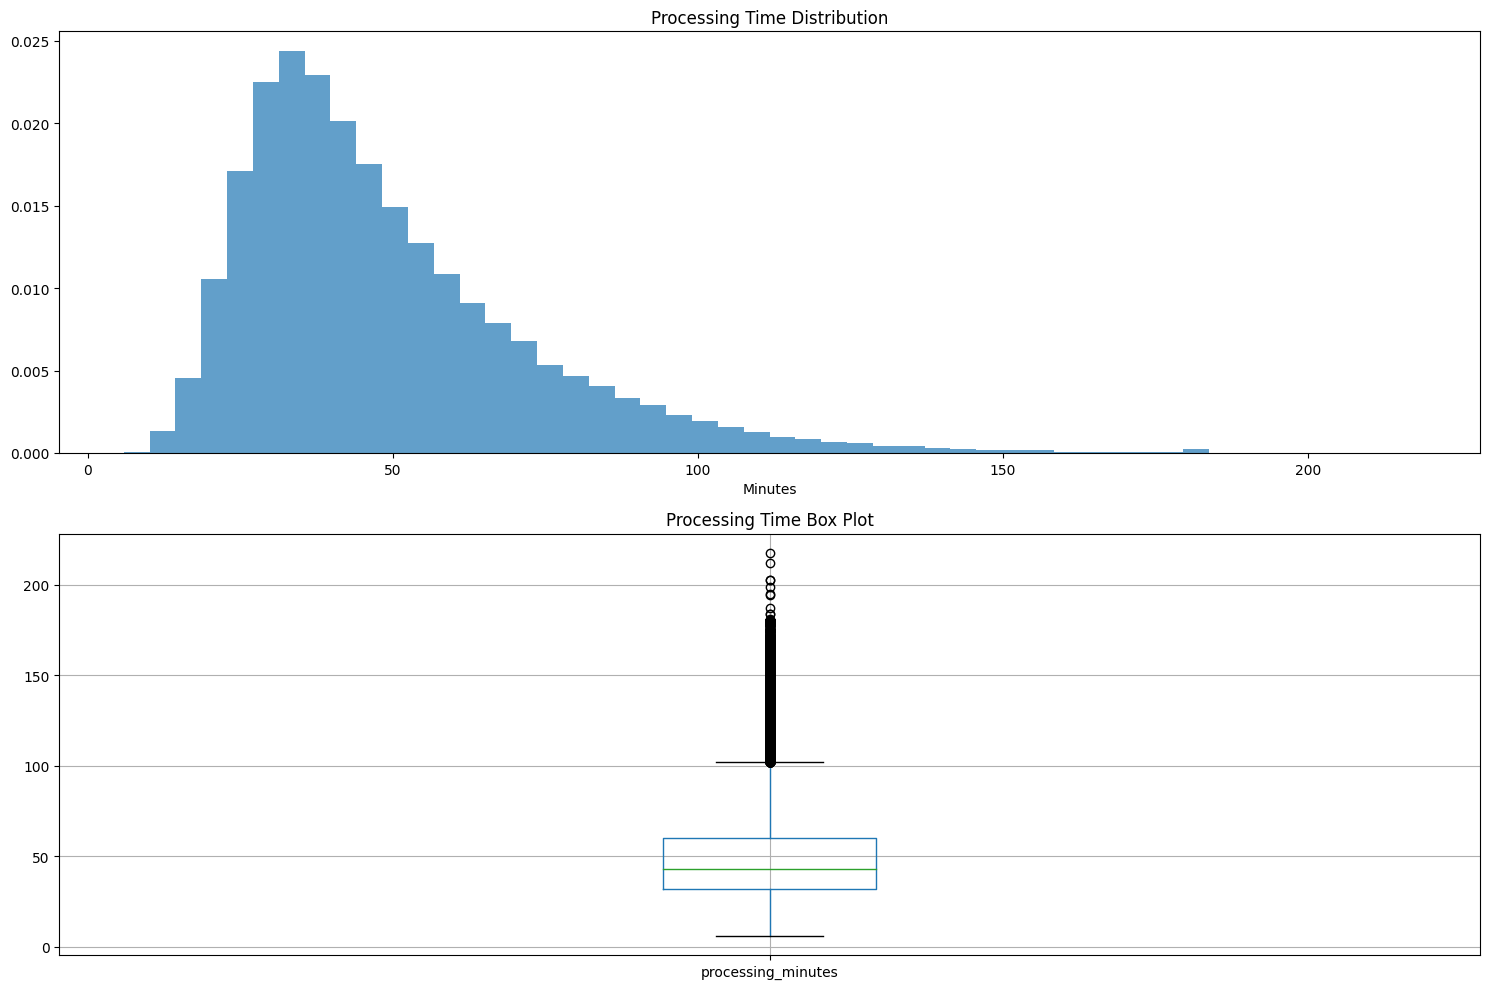


Outlier Analysis:
IQR method outliers: 7370 (3.7%)
Values > 480 min (8 hours): 0
Values < 5 min: 0


In [43]:
# Basic statistics
stats = train_df['processing_minutes'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
skew = train_df['processing_minutes'].skew()
kurtosis = train_df['processing_minutes'].kurtosis()

print("\nDescriptive Statistics:")
print(stats)
print(f"Skewness: {skew:.3f}")
print(f"Kurtosis: {kurtosis:.3f}")

# Distribution analysis
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Histogram with KDE
axes[0].hist(train_df['processing_minutes'], bins=50, alpha=0.7, density=True)
axes[0].set_title("Processing Time Distribution")
axes[0].set_xlabel("Minutes")

# Box plot
train_df.boxplot(column='processing_minutes', ax=axes[1])
axes[1].set_title("Processing Time Box Plot")

plt.tight_layout()
plt.show()

# Outlier analysis
Q1 = train_df['processing_minutes'].quantile(0.25)
Q3 = train_df['processing_minutes'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_df[(train_df['processing_minutes'] < lower_bound) | 
                    (train_df['processing_minutes'] > upper_bound)]

print(f"\nOutlier Analysis:")
print(f"IQR method outliers: {len(outliers)} ({len(outliers)/len(train_df)*100:.1f}%)")
print(f"Values > 480 min (8 hours): {(train_df['processing_minutes'] > 480).sum()}")
print(f"Values < 5 min: {(train_df['processing_minutes'] < 5).sum()}")

In [44]:
# Task-Based IQR Outlier Handling Implementation
print("=== TASK-BASED IQR OUTLIER HANDLING ===")
print("Applying IQR method to each task separately to remove outliers...")

# Implement task-based IQR outlier removal function
def handle_outliers_iqr_by_task(df):
    """
    Handle outliers for each task separately using IQR method
    """
    df_cleaned = df.copy()
    handling_stats = {}
    all_outlier_indices = []  # Track all indices to remove
    
    print(f"\n🔧 APPLYING IQR METHOD:")
    print("Task       | Original | Removed | Lower_Bound | Upper_Bound")
    print("-" * 65)
    
    for task_id in sorted(df['task_id'].unique()):
        task_mask = df['task_id'] == task_id
        task_data = df.loc[task_mask, 'processing_minutes']
        
        if len(task_data) < 10:  # Skip tasks with too few samples
            continue
        
        original_count = len(task_data)
        
        # Apply IQR method
        Q1 = task_data.quantile(0.25)
        Q3 = task_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Find outliers to REMOVE
        outlier_mask = (task_data < lower_bound) | (task_data > upper_bound)
        outlier_indices = task_data[outlier_mask].index
        all_outlier_indices.extend(outlier_indices)
        
        removed_count = len(outlier_indices)
        final_count = original_count - removed_count
        
        handling_stats[task_id] = {
            'original_count': original_count,
            'removed_count': removed_count,
            'final_count': final_count,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }
        
        print(f"{task_id:10s} | {original_count:8d} | {removed_count:7d} | {lower_bound:11.1f} | {upper_bound:11.1f}")
    
    # Remove all outlier indices at once
    df_cleaned = df_cleaned.drop(all_outlier_indices)
    return df_cleaned, handling_stats

# Apply IQR-based outlier removal
print("\n" + "="*80)
print("APPLYING IQR-BASED OUTLIER REMOVAL:")

# Apply IQR removal method for all tasks
train_df_iqr_removed, stats_iqr = handle_outliers_iqr_by_task(train_df)

# Show impact on data distribution
print(f"\n" + "="*80)
print("📊 IQR OUTLIER REMOVAL RESULTS:")
print(f"Original dataset: {len(train_df)} rows")
print(f"IQR cleaned dataset: {len(train_df_iqr_removed)} rows ({((len(train_df) - len(train_df_iqr_removed))/len(train_df)*100):.1f}% lost)")

print(f"\nIMPACT ON PROCESSING TIMES:")
print(f"                    | Mean   | Std    | Min   | Max    | Skewness")
print("-" * 65)
print(f"Original           | {train_df['processing_minutes'].mean():6.1f} | {train_df['processing_minutes'].std():6.1f} | {train_df['processing_minutes'].min():5.1f} | {train_df['processing_minutes'].max():6.1f} | {train_df['processing_minutes'].skew():8.2f}")
print(f"IQR Cleaned        | {train_df_iqr_removed['processing_minutes'].mean():6.1f} | {train_df_iqr_removed['processing_minutes'].std():6.1f} | {train_df_iqr_removed['processing_minutes'].min():5.1f} | {train_df_iqr_removed['processing_minutes'].max():6.1f} | {train_df_iqr_removed['processing_minutes'].skew():8.2f}")

# Show task-wise outlier removal statistics
print(f"\n📋 TASK-WISE OUTLIER REMOVAL SUMMARY:")
total_removed = 0
for task_id, stats in stats_iqr.items():
    removed_pct = (stats['removed_count'] / stats['original_count']) * 100
    total_removed += stats['removed_count']
    if stats['removed_count'] > 0:
        print(f"{task_id}: {stats['removed_count']}/{stats['original_count']} removed ({removed_pct:.1f}%)")

print(f"\nTotal outliers removed across all tasks: {total_removed}")

# Apply the IQR method
print(f"\n🔧 APPLYING IQR-BASED OUTLIER REMOVAL...")
train_df_final = train_df_iqr_removed.copy()
print(f"✅ Final dataset ready: {len(train_df_final)} rows")
print(f"✅ Outliers removed using IQR method on task-by-task basis")
print(f"✅ Processing time range: {train_df_final['processing_minutes'].min():.1f} - {train_df_final['processing_minutes'].max():.1f} minutes")
print(f"✅ Data loss: {((len(train_df) - len(train_df_final))/len(train_df)*100):.1f}%")

# Update the global train_df variable
train_df = train_df_final
print(f"\n✅ train_df updated with IQR-cleaned data")
print(f"📈 Ready for model training with {len(train_df)} clean samples")

print(train_df.head(10))
print(len(train_df))

=== TASK-BASED IQR OUTLIER HANDLING ===
Applying IQR method to each task separately to remove outliers...

APPLYING IQR-BASED OUTLIER REMOVAL:

🔧 APPLYING IQR METHOD:
Task       | Original | Removed | Lower_Bound | Upper_Bound
-----------------------------------------------------------------
TASK-001   |    10706 |     172 |        26.4 |        83.2
TASK-002   |     5239 |      89 |        14.2 |       120.9
TASK-003   |     6901 |     175 |        10.0 |       111.0
TASK-004   |     9516 |     148 |        12.3 |        41.6
TASK-005   |    16258 |     246 |        16.8 |        53.8
TASK-006   |     6103 |     174 |         5.0 |        76.0
TASK-007   |    12675 |     300 |         3.5 |        43.5
TASK-008   |    12267 |     246 |         5.5 |        53.1
TASK-009   |     7616 |     124 |        21.0 |        59.7
TASK-010   |    10028 |     176 |        14.5 |        59.6
TASK-011   |    10902 |     163 |        16.4 |        46.9
TASK-012   |     5472 |      91 |        18.5 |

##### Temporal Pattern Analysis


Hour of Day Analysis:
      count  median   mean    std
hour                             
9     57895   42.11  47.65  22.56
10    57892   41.90  47.48  22.33
11    20134   41.73  47.12  22.12
12    19372   42.41  47.93  22.71
13    19052   43.92  49.62  23.09
Peak hour of day: 13 (43.9 min)
Off-peak hour of day: 11 (41.7 min)
Variation (std): 0.9 minutes

Day of Week Analysis:
             count  median   mean    std
day_of_week                             
0            51043   42.42  48.01  22.60
1            36884   42.59  48.26  22.74
2            35356   42.37  47.89  22.41
3            34830   42.36  48.17  22.86
4            35773   41.88  47.32  22.24
Peak day of week: 1 (42.6 min)
Off-peak day of week: 4 (41.9 min)
Variation (std): 0.3 minutes

Month Analysis:
       count  median   mean    std
month                             
1      15408   44.10  50.08  23.44
2      14306   43.12  48.62  22.70
3      15970   42.78  48.30  22.70
4      13125   42.16  47.67  22.22
5      153

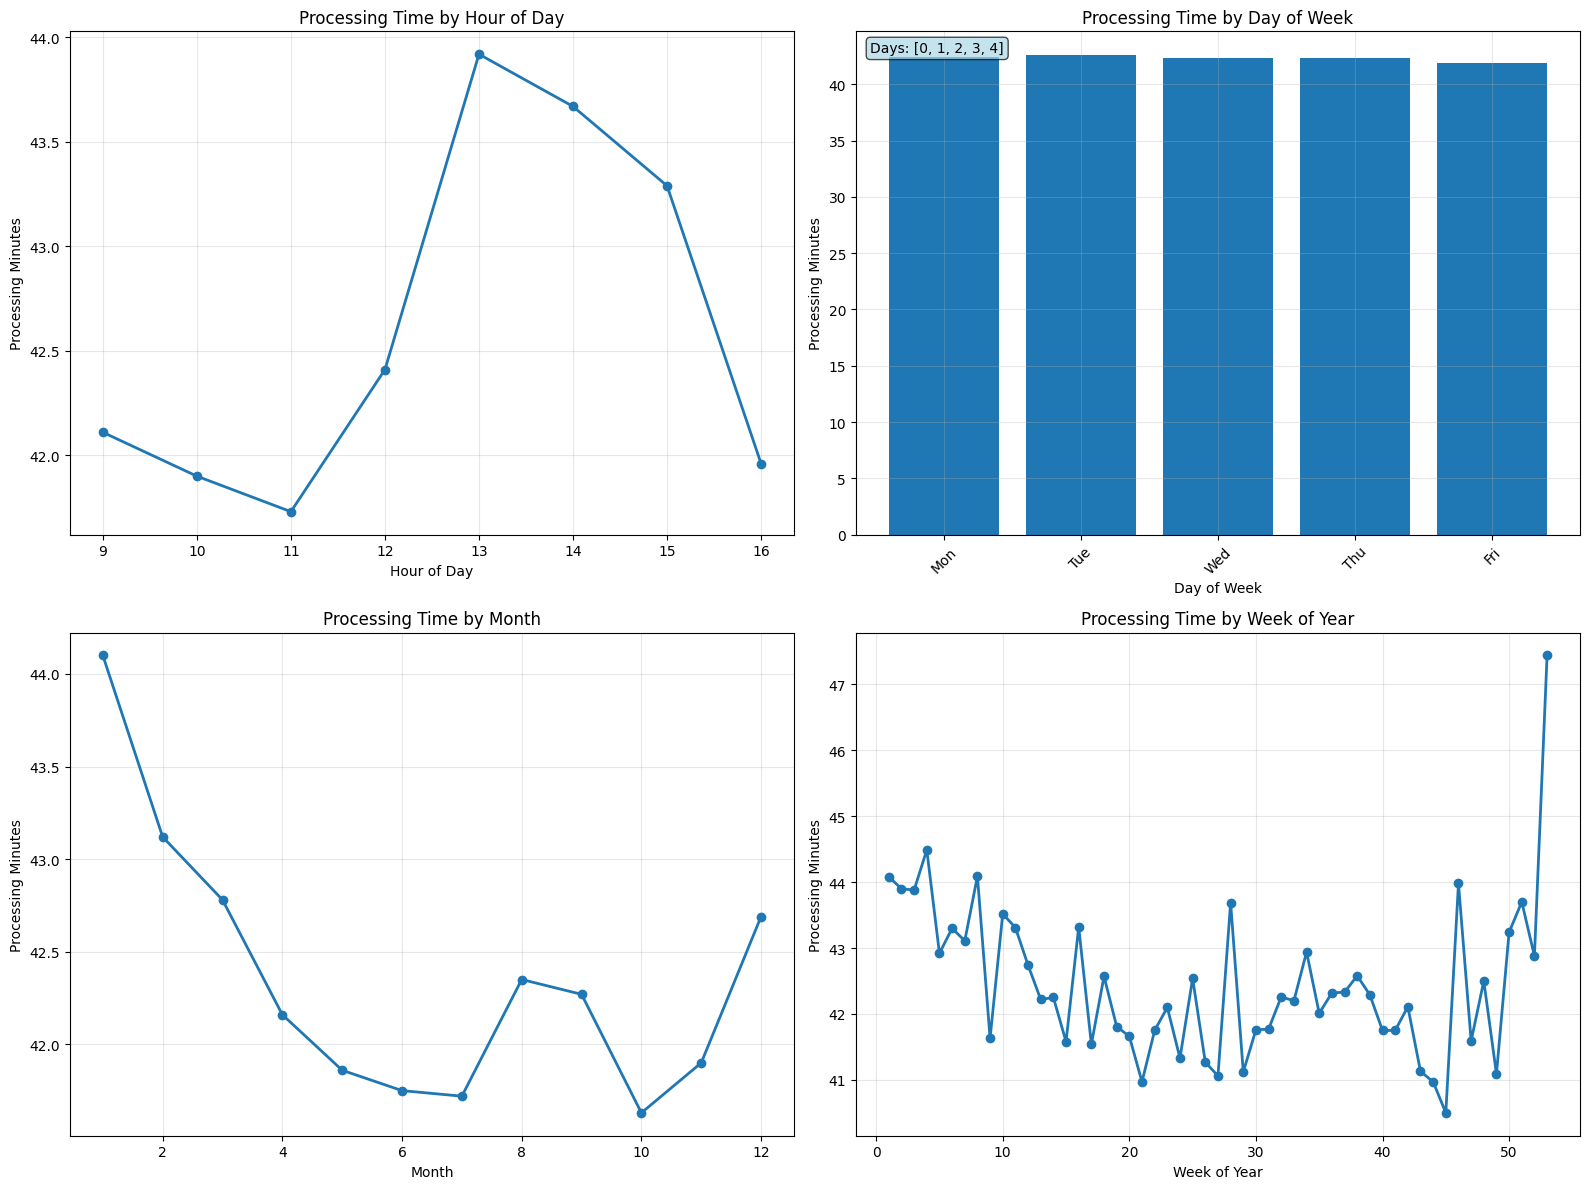

In [45]:
# Create temporary time features for EDA
eda_df = train_df.copy()
eda_df['hour'] = pd.to_datetime(eda_df['appointment_time'], format='%H:%M:%S', errors='coerce').dt.hour
eda_df['day_of_week'] = eda_df['appointment_date'].dt.dayofweek
eda_df['month'] = eda_df['appointment_date'].dt.month
eda_df['day_of_month'] = eda_df['appointment_date'].dt.day
eda_df['week_of_year'] = eda_df['appointment_date'].dt.isocalendar().week

# Comprehensive time analysis
time_analyses = {
    'Hour of Day': ('hour', 24),
    'Day of Week': ('day_of_week', 7), 
    'Month': ('month', 12),
    'Week of Year': ('week_of_year', 53)
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (title, (col, max_val)) in enumerate(time_analyses.items()):
    # Statistical analysis
    time_stats = eda_df.groupby(col)['processing_minutes'].agg(['count', 'median', 'mean', 'std']).round(2)
    
    if col == 'day_of_week':
        # Create mapping for day names
        day_mapping = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
        
        # Plot with correct positions and labels
        axes[i].bar(range(len(time_stats)), time_stats['median'])
        axes[i].set_xticks(range(len(time_stats)))
        
        # Create labels for ONLY the days that exist in your data
        day_labels = [day_mapping[day_idx] for day_idx in time_stats.index]
        axes[i].set_xticklabels(day_labels)
        axes[i].tick_params(axis='x', rotation=45)
        
        # Add annotation showing the actual day numbers
        axes[i].text(0.02, 0.98, f"Days: {list(time_stats.index)}", 
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
    else:
        axes[i].plot(time_stats.index, time_stats['median'], marker='o', linewidth=2)
    
    axes[i].set_title(f"Processing Time by {title}")
    axes[i].set_xlabel(title)
    axes[i].set_ylabel("Processing Minutes")
    axes[i].grid(True, alpha=0.3)
    
    print(f"\n{title} Analysis:")
    print(time_stats.head())
    
    # Find patterns
    peak_time = time_stats['median'].idxmax()
    off_peak_time = time_stats['median'].idxmin()
    variation = time_stats['median'].std()
    
    print(f"Peak {title.lower()}: {peak_time} ({time_stats.loc[peak_time, 'median']:.1f} min)")
    print(f"Off-peak {title.lower()}: {off_peak_time} ({time_stats.loc[off_peak_time, 'median']:.1f} min)")
    print(f"Variation (std): {variation:.1f} minutes")

plt.tight_layout()
plt.show()

# Clean up
del eda_df

##### Time Series Analysis

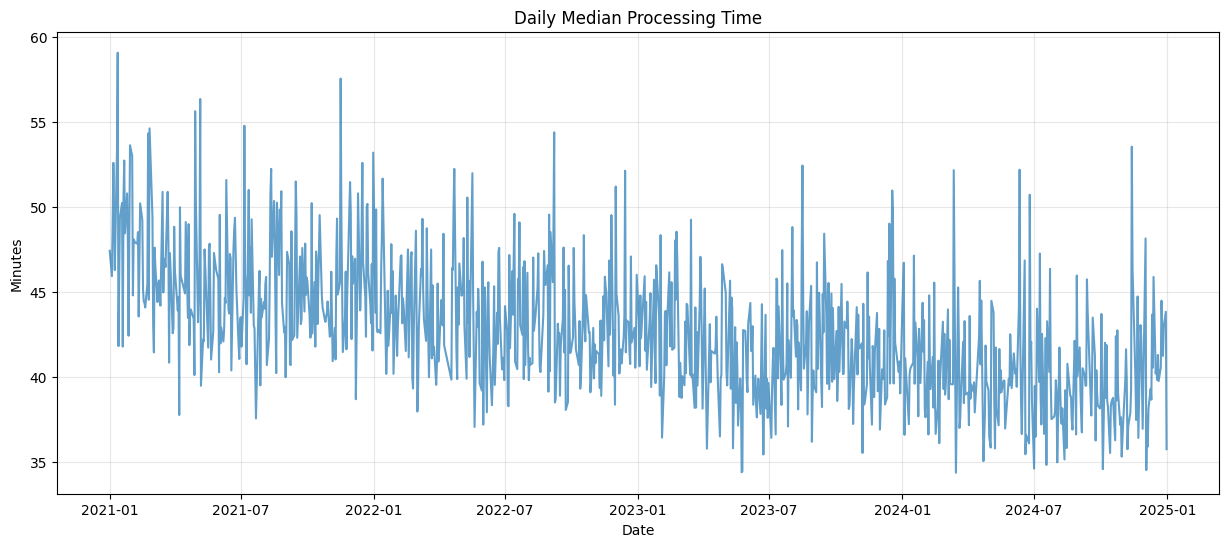

Autocorrelation Analysis:


<Figure size 1200x600 with 0 Axes>

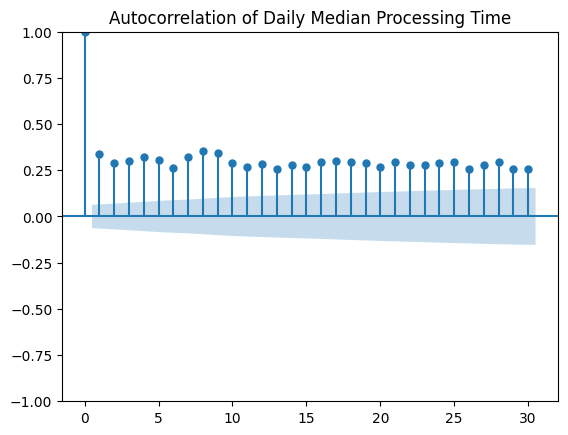

Significant autocorrelations (>0.5): []

Trend Analysis:
Slope: -0.0077 minutes/day
R-squared: 0.2955
P-value: 0.000000


In [46]:
# Prepare time series data
ts_df = train_df.groupby('appointment_date')['processing_minutes'].agg(['median']).reset_index()
ts_df = ts_df.sort_values('appointment_date')

# Plot Daily Median Processing Time
plt.figure(figsize=(15, 6))
plt.plot(ts_df['appointment_date'], ts_df['median'], alpha=0.7)
plt.title("Daily Median Processing Time")
plt.ylabel("Minutes")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.show()

# Autocorrelation analysis
print("Autocorrelation Analysis:")
lags = min(30, len(ts_df) // 4)
autocorr = acf(ts_df['median'].dropna(), nlags=lags)

plt.figure(figsize=(12, 6))
plot_acf(ts_df['median'].dropna(), lags=lags, alpha=0.05)
plt.title("Autocorrelation of Daily Median Processing Time")
plt.show()

# Find significant lags
significant_lags = []
for i, corr in enumerate(autocorr[1:], 1):
    if abs(corr) > 0.5:  # Threshold for significance
        significant_lags.append((i, corr))

print(f"Significant autocorrelations (>0.5): {significant_lags[:5]}")

# Trend analysis
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(
    range(len(ts_df)), ts_df['median']
)

print(f"\nTrend Analysis:")
print(f"Slope: {slope:.4f} minutes/day")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.6f}")

##### Categorical Analysis

=== TASK ANALYSIS ===
          count  median   mean    std    min     max
task_id                                             
TASK-013  14001   76.79  80.39  25.91  20.02  154.89
TASK-017  10541   73.73  76.15  19.69  26.23  131.97
TASK-015  13608   71.86  74.48  21.76  19.67  137.51
TASK-002   5150   66.20  67.96  18.36  24.44  120.64
TASK-003   6726   58.54  60.56  17.68  18.69  110.74
TASK-012   5381   58.13  59.38  14.26  19.97   99.93
TASK-019  11827   55.62  56.79  13.72  21.19   95.65
TASK-001  10534   54.30  54.95  10.07  28.01   83.09
TASK-016  12284   47.76  48.35   8.19  26.40   71.27
TASK-009   7492   39.92  40.37   6.92  21.15   59.66
TASK-006   5929   39.15  40.64  12.24  12.43   75.93
TASK-014  12412   39.10  39.66   7.03  19.99   59.47
TASK-010   9852   36.26  37.02   7.98  16.18   59.49
TASK-005  16012   34.85  35.38   6.61  17.03   53.82
TASK-011  10739   31.31  31.68   5.37  16.59   46.83
TASK-018   7634   28.82  29.50   7.15  10.64   49.71
TASK-008  12021   28.62 

C:\Users\prave\AppData\Local\Temp\ipykernel_12948\3698689284.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  task_stats = train_df.groupby('task_id')['processing_minutes'].agg([


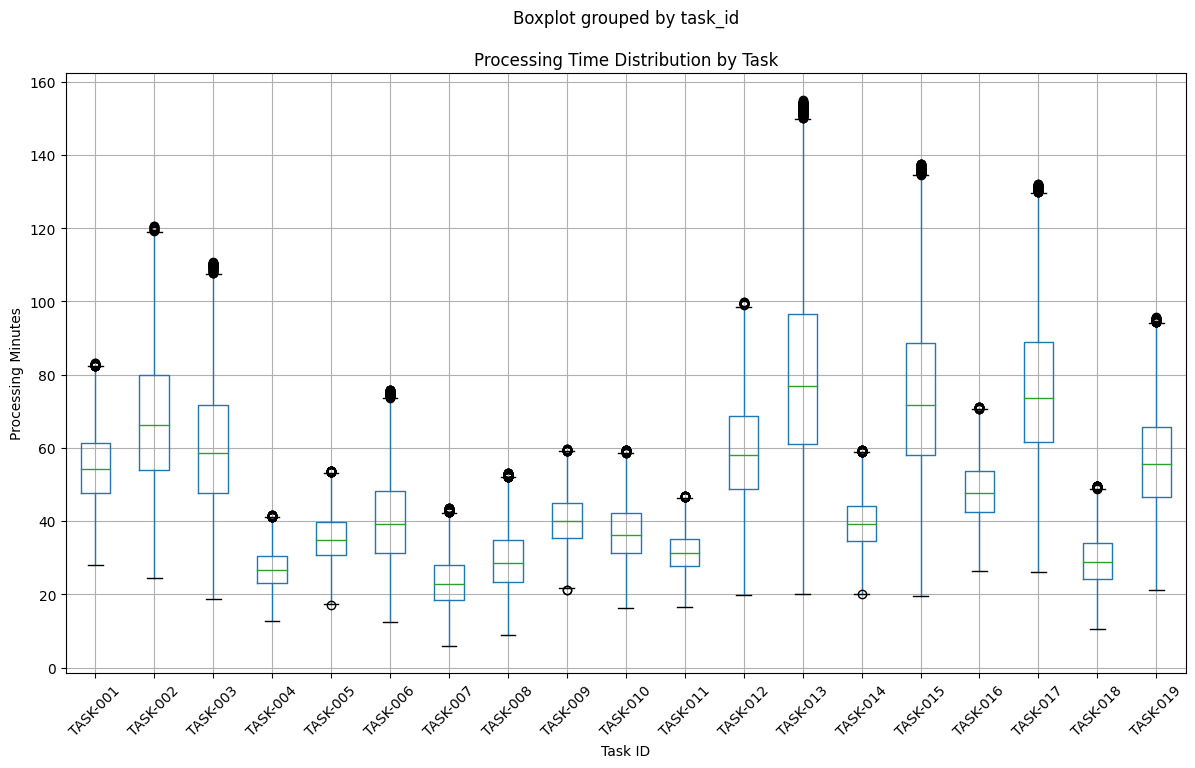


=== SECTION ANALYSIS ===
            count  median   mean    std    min     max
section_id                                            
SEC-005     40021   61.10  65.75  26.89  19.67  154.89
SEC-001     15684   56.76  59.22  14.70  24.44  120.64
SEC-006     42286   51.36  54.24  20.49  10.64  131.97
SEC-004     25972   35.58  39.44  13.70  16.18   99.93
SEC-002     38035   34.82  38.60  15.07  12.43  110.74
SEC-003     31888   28.76  29.75   9.88   5.92   59.66


C:\Users\prave\AppData\Local\Temp\ipykernel_12948\3698689284.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  section_stats = train_df.groupby('section_id')['processing_minutes'].agg([


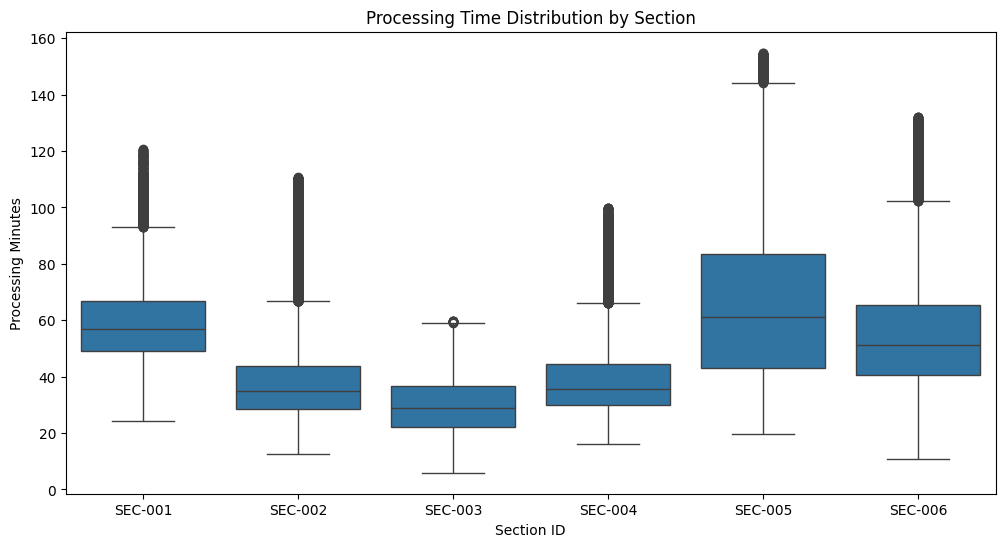


=== PREDICTIVE POWER ASSESSMENT ===
Task ID explains 65.7% of variance
Section ID explains 38.8% of variance


C:\Users\prave\AppData\Local\Temp\ipykernel_12948\3698689284.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  task_variance_explained = 1 - (train_df.groupby('task_id')['processing_minutes'].var().mean() / total_variance)
C:\Users\prave\AppData\Local\Temp\ipykernel_12948\3698689284.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  section_variance_explained = 1 - (train_df.groupby('section_id')['processing_minutes'].var().mean() / total_variance)


In [47]:
# Task analysis
print("=== TASK ANALYSIS ===")
task_stats = train_df.groupby('task_id')['processing_minutes'].agg([
    'count', 'median', 'mean', 'std', 'min', 'max'
]).round(2).sort_values('median', ascending=False)

print(task_stats)

# Task visualization
plt.figure(figsize=(14, 8))
train_df.boxplot(column='processing_minutes', by='task_id', ax=plt.gca())
plt.title("Processing Time Distribution by Task")
plt.xlabel("Task ID")
plt.ylabel("Processing Minutes")
plt.xticks(rotation=45)
plt.show()

# Section analysis
print("\n=== SECTION ANALYSIS ===")
section_stats = train_df.groupby('section_id')['processing_minutes'].agg([
    'count', 'median', 'mean', 'std', 'min', 'max'
]).round(2).sort_values('median', ascending=False)

print(section_stats)

# Section visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df, x='section_id', y='processing_minutes')
plt.title("Processing Time Distribution by Section")
plt.xlabel("Section ID")
plt.ylabel("Processing Minutes")
plt.show()

# Variance analysis
print(f"\n=== PREDICTIVE POWER ASSESSMENT ===")
total_variance = train_df['processing_minutes'].var()
task_variance_explained = 1 - (train_df.groupby('task_id')['processing_minutes'].var().mean() / total_variance)
section_variance_explained = 1 - (train_df.groupby('section_id')['processing_minutes'].var().mean() / total_variance)

print(f"Task ID explains {task_variance_explained:.1%} of variance")
print(f"Section ID explains {section_variance_explained:.1%} of variance")

##### Staffing Analysis

Analyzing staffing levels and their relationship to processing times...
Staffing Correlations with Processing Time:
processing_minutes         1.000000
total_task_time_minutes    0.405785
employees_on_duty          0.396253
load_per_employee          0.075206
Name: processing_minutes, dtype: float64

Processing Time by Staffing Level:
                   count  median   mean    std
employees_on_duty                             
Low                55843   34.65  38.47  16.78
Medium-Low         56997   39.29  44.15  19.41
Medium-High        37619   45.78  51.06  21.95
High               43427   57.00  62.39  25.50


C:\Users\prave\AppData\Local\Temp\ipykernel_12948\2576631046.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  staffing_impact = staffing_analysis.groupby(staffing_bins)['processing_minutes'].agg([


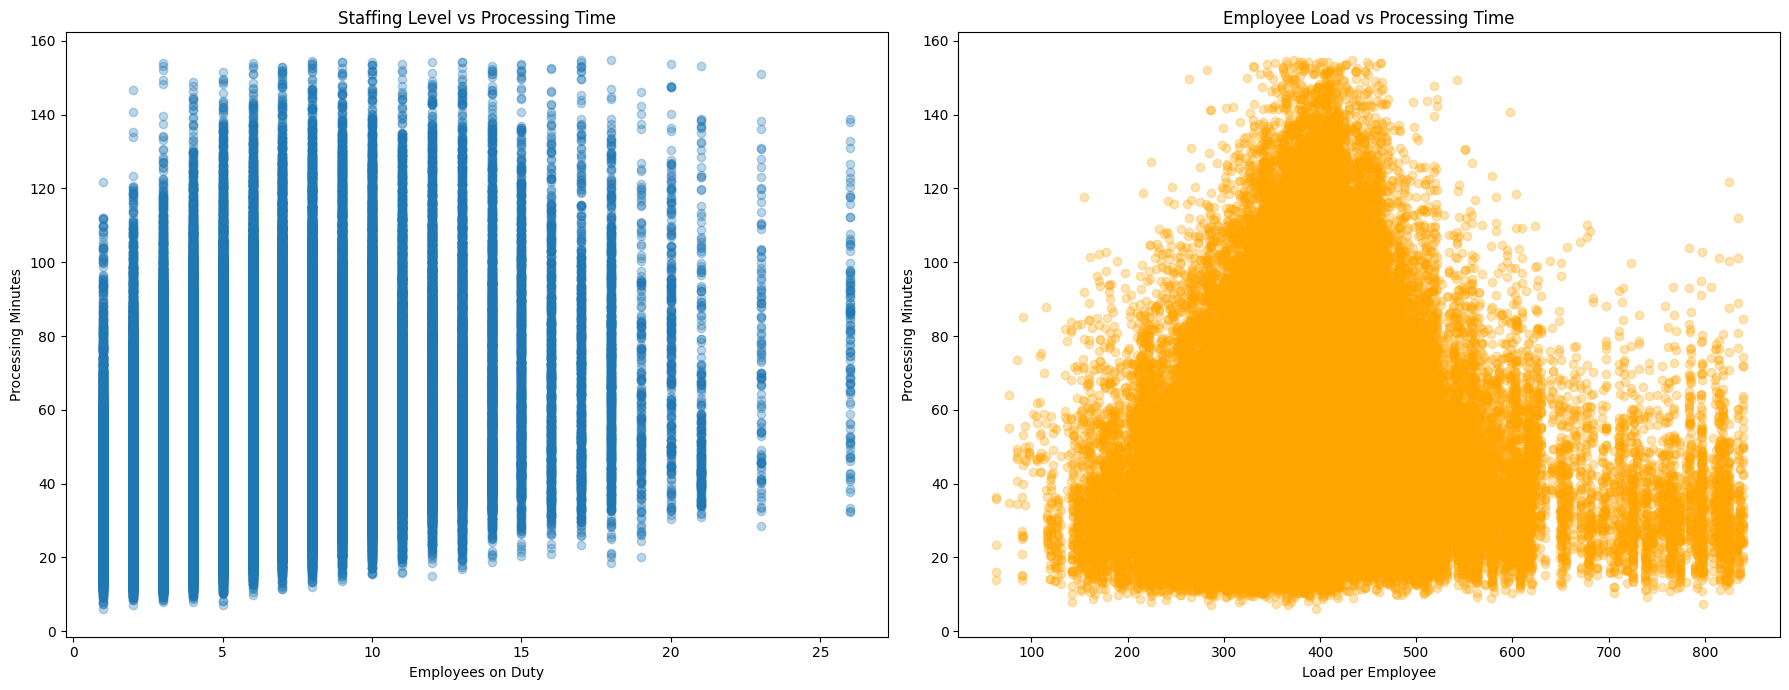

In [48]:
print("Analyzing staffing levels and their relationship to processing times...")

# Convert staffing date to datetime first
staffing_fixed = staffing.copy()
staffing_fixed['date'] = pd.to_datetime(staffing_fixed['date'], errors='coerce')

# Merge with staffing data for analysis
staffing_analysis = train_df.merge(
    staffing_fixed[['date', 'section_id', 'employees_on_duty', 'total_task_time_minutes']], 
    left_on=['appointment_date', 'section_id'], 
    right_on=['date', 'section_id'], 
    how='left'
)

# Calculate load per employee
staffing_analysis['load_per_employee'] = (
    staffing_analysis['total_task_time_minutes'] / 
    staffing_analysis['employees_on_duty'].replace(0, np.nan)
)
# Staffing vs processing time correlation
correlations = staffing_analysis[['processing_minutes', 'employees_on_duty', 
                                'total_task_time_minutes', 'load_per_employee']].corr()

print("Staffing Correlations with Processing Time:")
print(correlations['processing_minutes'].sort_values(ascending=False))

# Staffing level analysis
staffing_bins = pd.qcut(staffing_analysis['employees_on_duty'].dropna(), 
                        q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

staffing_impact = staffing_analysis.groupby(staffing_bins)['processing_minutes'].agg([
    'count', 'median', 'mean', 'std'
]).round(2)

print(f"\nProcessing Time by Staffing Level:")
print(staffing_impact)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Staffing vs processing time scatter
axes[0].scatter(staffing_analysis['employees_on_duty'], 
                staffing_analysis['processing_minutes'], alpha=0.3)
axes[0].set_xlabel("Employees on Duty")
axes[0].set_ylabel("Processing Minutes")
axes[0].set_title("Staffing Level vs Processing Time")

# Load per employee vs processing time
axes[1].scatter(staffing_analysis['load_per_employee'], 
                staffing_analysis['processing_minutes'], alpha=0.3, color='orange')
axes[1].set_xlabel("Load per Employee")
axes[1].set_ylabel("Processing Minutes")
axes[1].set_title("Employee Load vs Processing Time")

plt.tight_layout()
plt.show()

##### Correlation and Feature Selection Insights


=== CORRELATION ANALYSIS FOR FEATURE ENGINEERING ===
Analyzing raw features to guide feature engineering decisions...
Analyzing correlations for: ['processing_minutes', 'hour', 'day_of_week', 'month', 'day_of_month', 'appointments_per_task_daily', 'employees_on_duty', 'total_task_time_minutes', 'load_per_employee', 'num_documents', 'queue_number', 'satisfaction_rating']


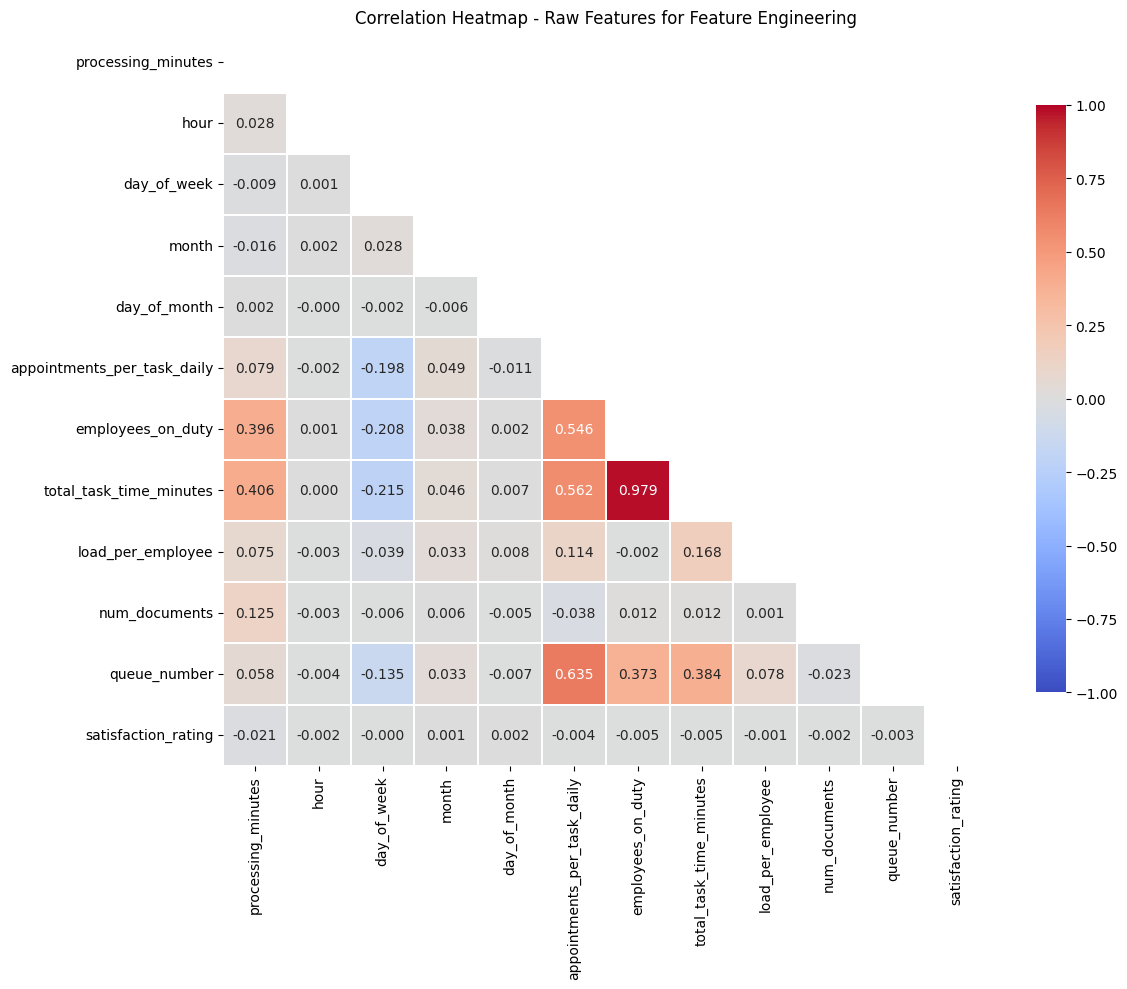


=== CORRELATIONS WITH TARGET (processing_minutes) ===
total_task_time_minutes        0.406
employees_on_duty              0.396
num_documents                  0.125
appointments_per_task_daily    0.079
load_per_employee              0.075
queue_number                   0.058
hour                           0.028
satisfaction_rating            0.021
month                          0.016
day_of_week                    0.009
day_of_month                   0.002
Name: processing_minutes, dtype: float64


In [49]:
print("\n=== CORRELATION ANALYSIS FOR FEATURE ENGINEERING ===")
print("Analyzing raw features to guide feature engineering decisions...")

# Use the cleaned train_df (after outlier handling but before feature engineering)
corr_df = train_df.copy()

# Add basic time features for correlation analysis
corr_df['hour'] = pd.to_datetime(corr_df['appointment_time'], format='%H:%M:%S', errors='coerce').dt.hour
corr_df['day_of_week'] = corr_df['appointment_date'].dt.dayofweek
corr_df['month'] = corr_df['appointment_date'].dt.month
corr_df['day_of_month'] = corr_df['appointment_date'].dt.day

# Add basic staffing features for correlation
staffing_for_corr = staffing.copy()
staffing_for_corr['date'] = pd.to_datetime(staffing_for_corr['date'], errors='coerce')
corr_df = corr_df.merge(
    staffing_for_corr[['date', 'section_id', 'employees_on_duty', 'total_task_time_minutes']], 
    left_on=['appointment_date', 'section_id'], 
    right_on=['date', 'section_id'], 
    how='left'
)
corr_df['load_per_employee'] = corr_df['total_task_time_minutes'] / corr_df['employees_on_duty'].replace(0, np.nan)

# Select numeric columns for correlation analysis
numeric_features_for_corr = [
    'processing_minutes',  # Target
    'hour', 'day_of_week', 'month', 'day_of_month',
    'appointments_per_task_daily',
    'employees_on_duty', 'total_task_time_minutes', 'load_per_employee'
]

# Add booking features if they exist
if 'num_documents' in corr_df.columns:
    numeric_features_for_corr.append('num_documents')
if 'queue_number' in corr_df.columns:
    numeric_features_for_corr.append('queue_number')
if 'satisfaction_rating' in corr_df.columns:
    numeric_features_for_corr.append('satisfaction_rating')

# Filter to existing columns
existing_numeric_features = [col for col in numeric_features_for_corr if col in corr_df.columns]

print(f"Analyzing correlations for: {existing_numeric_features}")

# Calculate correlation matrix
corr_matrix = corr_df[existing_numeric_features].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap="coolwarm", 
    center=0, 
    vmin=-1, 
    vmax=1,
    annot=True, 
    fmt=".3f", 
    linewidths=0.2, 
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap - Raw Features for Feature Engineering")
plt.tight_layout()
plt.show()

# Show correlations with target specifically
target_correlations = corr_matrix['processing_minutes'].drop('processing_minutes').abs().sort_values(ascending=False)
print(f"\n=== CORRELATIONS WITH TARGET (processing_minutes) ===")
print(target_correlations.round(3))


# Clean up
del corr_df

#### Categorical Feature Selection Check

In [50]:
# print("\n=== QUICK CATEGORICAL FEATURE ANALYSIS ===")

# # Simple variance explained check for categorical features
# def quick_categorical_check(df, cat_cols, target_col):
#     results = []
#     total_var = df[target_col].var()
    
#     for col in cat_cols:
#         if col in df.columns:
#             # Variance explained (like R-squared for categorical)
#             within_var = df.groupby(col)[target_col].var().mean()
#             var_explained = 1 - (within_var / total_var)
            
#             # Number of unique categories
#             n_categories = df[col].nunique()
            
#             # Sample size per category
#             min_samples = df.groupby(col).size().min()
            
#             results.append({
#                 'feature': col,
#                 'variance_explained': var_explained,
#                 'n_categories': n_categories,
#                 'min_samples_per_cat': min_samples
#             })
    
#     return pd.DataFrame(results).sort_values('variance_explained', ascending=False)

# # Check current categorical features
# cat_check = quick_categorical_check(feat_df, categorical_cols, target_col)
# print("Current categorical features impact:")
# print(cat_check.round(4))

# # Quick recommendation
# print(f"\n💡 QUICK INSIGHTS:")
# high_impact = cat_check[cat_check['variance_explained'] > 0.1]
# low_impact = cat_check[cat_check['variance_explained'] < 0.02]

# print(f"✅ Strong features (keep): {high_impact['feature'].tolist()}")
# print(f"❌ Weak features (consider removing): {low_impact['feature'].tolist()}")
# print(f"⚠️  High cardinality features: {cat_check[cat_check['n_categories'] > 50]['feature'].tolist()}")

### Feature Engineering Utilities

In [51]:
def add_time_features(df, date_col='appointment_date', time_col='appointment_time'):
    out = df.copy()
    out['year'] = out[date_col].dt.year
    out['day'] = out[date_col].dt.day
    out['day_of_week'] = out[date_col].dt.weekday  # Monday=0
    out['month'] = out[date_col].dt.month
    
    # Days since start of dataset
    min_date = out[date_col].min()
    out['days_since_start'] = (out[date_col] - min_date).dt.days

    # Time-of-day features
    # Normalize time string to HH:MM:SS then parse hour/minute
    def parse_hhmm(s):
        if pd.isna(s):
            return (np.nan, np.nan)
        parts = str(s).split(':')
        if len(parts) == 2:
            hh, mm = parts
            return (int(hh), int(mm))
        if len(parts) >= 3:
            hh, mm, _ = parts
            return (int(hh), int(mm))
        return (np.nan, np.nan)

    hhmm = out[time_col].apply(parse_hhmm)
    out['hour'] = [h for h, m in hhmm]
    out['minute'] = [m for h, m in hhmm]

    # cyclical encodings
    # hour 
    out['hour_sin'] = np.sin(2*np.pi*out['hour']/24.0)
    out['hour_cos'] = np.cos(2*np.pi*out['hour']/24.0)
    # day of week
    out['dow_sin'] = np.sin(2*np.pi*out['day_of_week']/7.0)
    out['dow_cos'] = np.cos(2*np.pi*out['day_of_week']/7.0)
    # month
    out['month_sin'] = np.sin(2*np.pi*out['month']/12.0)
    out['month_cos'] = np.cos(2*np.pi*out['month']/12.0)
    return out

def add_booking_features(df):
    out = df.copy()
    
    # Check if columns exist, if not create them with NaN values
    if 'num_documents' in out.columns:
        out['num_documents_log1p'] = np.log1p(out['num_documents'].clip(lower=0))
    else:
        out['num_documents'] = np.nan
        out['num_documents_log1p'] = np.nan
        
    if 'queue_number' in out.columns:
        out['queue_number_log1p'] = np.log1p(out['queue_number'].clip(lower=0))
    else:
        out['queue_number'] = np.nan
        out['queue_number_log1p'] = np.nan
    
    return out

def prepare_staffing_features(staffing_df):
    s = staffing_df.copy()
    s['date'] = pd.to_datetime(s['date'], errors='coerce')
    
    # Core load calculation
    s['load_per_employee'] = s['total_task_time_minutes'] / s['employees_on_duty'].replace(0, np.nan)

    # Sort by section and date for proper lag calculation
    s = s.sort_values(['section_id', 'date'])
    
    # Add lag features (previous day's values)
    s['employees_on_duty_lag1'] = s.groupby('section_id')['employees_on_duty'].shift(1)
    s['total_task_time_minutes_lag1'] = s.groupby('section_id')['total_task_time_minutes'].shift(1)
    s['load_per_employee_lag1'] = s.groupby('section_id')['load_per_employee'].shift(1)
    
    # 7-day rolling mean for employees (trend indicator)
    s = s.sort_values(['section_id','date'])
    s['employees_on_duty_rollmean7'] = s.groupby('section_id')['employees_on_duty'].rolling(7, min_periods=1).mean().reset_index(0,drop=True)
    
    # Staffing level categories
    s['staffing_level_cat'] = pd.qcut(s['employees_on_duty'], 
                                    q=5, labels=['Very_Low', 'Low', 'Medium', 'High', 'Very_High'], 
                                    duplicates='drop')
    return s

def add_staffing_features(book_df, staffing_prepared):
    # Merge on date+section_id (appointment_date)
    out = book_df.merge(
        staffing_prepared,
        left_on=['appointment_date','section_id'],
        right_on=['date','section_id'],
        how='left',
        suffixes=('','_staff')
    )
    out = out.drop(columns=['date'], errors='ignore')
    return out

def add_advanced_volume_features(df):
    """Add volume-based features for workload prediction"""
    out = df.copy()
    
    # Daily volume features by section
    daily_volume = out.groupby(['appointment_date', 'section_id']).size().reset_index(name='daily_section_volume')
    out = out.merge(daily_volume, on=['appointment_date', 'section_id'], how='left')
    
    # Hourly volume features
    hourly_volume = out.groupby(['appointment_date', 'hour', 'section_id']).size().reset_index(name='hourly_section_volume')
    out = out.merge(hourly_volume, on=['appointment_date', 'hour', 'section_id'], how='left')
    
    # Task-specific volume features
    task_daily_volume = out.groupby(['appointment_date', 'task_id']).size().reset_index(name='daily_task_volume')
    out = out.merge(task_daily_volume, on=['appointment_date', 'task_id'], how='left')
    
    # Rolling volume features (requires sorting)
    out = out.sort_values(['section_id', 'appointment_date'])
    out['volume_rollmean7'] = out.groupby('section_id')['daily_section_volume'].rolling(7, min_periods=1).mean().reset_index(0,drop=True)
    
    # Volume percentiles within section
    out['volume_pct_rank'] = out.groupby('section_id')['daily_section_volume'].rank(pct=True)
    
    return out

def add_task_priority_features(df):
    """Add task-centric features to give task_id higher modeling priority"""
    out = df.copy()
    
    # Task × Time interactions (expand beyond just hour)
    out['task_day'] = out['task_id'].astype(str) + '_D' + out['day_of_week'].astype(str)
    out['task_month'] = out['task_id'].astype(str) + '_M' + out['month'].astype(str)
    
    # Task × Staffing interactions
    if 'employees_on_duty' in out.columns:
        # Bin staffing levels for interaction
        out['staffing_level'] = pd.qcut(out['employees_on_duty'].fillna(0), 
                                q=3, labels=['Low', 'Med', 'High'], duplicates='drop')
        out['task_staffing'] = out['task_id'].astype(str) + '_S' + out['staffing_level'].astype(str)
            
    # Task × Volume interactions  
    if 'appointments_per_task_daily' in out.columns:
        out['volume_level'] = pd.qcut(out['appointments_per_task_daily'], 
                                    q=3, labels=['Low', 'Med', 'High'], duplicates='drop')
        out['task_volume'] = out['task_id'].astype(str) + '_V' + out['volume_level'].astype(str)
    
    return out

### Build training feature table

In [52]:
# Base
feat_df = train_df.copy()

# Time features
feat_df = add_time_features(feat_df, date_col='appointment_date', time_col='appointment_time')

# Booking features
feat_df = add_booking_features(feat_df)

# Staffing features (optional but recommended)
staffing_prep = prepare_staffing_features(staffing)
feat_df = add_staffing_features(feat_df, staffing_prep)

# Apply task priority features
feat_df = add_task_priority_features(feat_df)

# Collect feature columns
target_col = 'processing_minutes'
# Prioritize task_id by creating task-specific time features
feat_df['task_hour'] = feat_df['task_id'].astype(str) + '_H' + feat_df['hour'].astype(str)
categorical_cols = [
    'task_id',           # Primary priority
    'task_hour',         # Task × Time
    #'task_day',          # Task × Day of week
    #'task_staffing',     # Task × Staffing level
    'task_volume',       # Task × Volume
    'section_id',        # Lower priority
    'staffing_level_cat',
]

numeric_cols = [
    # base numerics
    'num_documents_log1p',#'queue_number_log1p',
    # time numerics
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    #'hour_sin', 'hour_cos',
    'days_since_start', 

    # staffing numerics
    'load_per_employee',
    'employees_on_duty_rollmean7',
    'employees_on_duty_lag1',
    'total_task_time_minutes_lag1',
    'load_per_employee_lag1',
    
    # Volume features
    'daily_section_volume',
    'hourly_section_volume', 
    'daily_task_volume',
    'volume_rollmean7',
    'volume_pct_rank',
]

# Filter to columns that exist
numeric_cols = [c for c in numeric_cols if c in feat_df.columns]
categorical_cols = [c for c in categorical_cols if c in feat_df.columns]

# Drop rows with missing target
feat_df = feat_df.dropna(subset=[target_col]).copy()

print("Refined feature columns (removed redundant features):")
print("Categorical:", len(categorical_cols), categorical_cols[:10], "...")
print("Numeric:", len(numeric_cols), numeric_cols[:10], "...")
print("Total features:", len(categorical_cols) + len(numeric_cols))
print("Rows:", len(feat_df))

Refined feature columns (removed redundant features):
Categorical: 5 ['task_id', 'task_hour', 'task_volume', 'section_id', 'staffing_level_cat'] ...
Numeric: 11 ['num_documents_log1p', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'days_since_start', 'load_per_employee', 'employees_on_duty_rollmean7', 'employees_on_duty_lag1', 'total_task_time_minutes_lag1'] ...
Total features: 16
Rows: 193886


### Train / Validation Split

In [53]:
# Create a time-based split by appointment_date
feat_df = feat_df.sort_values('appointment_date')
split_date = feat_df['appointment_date'].quantile(0.8)  # last 20% as validation; adjust as needed

train_mask = feat_df['appointment_date'] <= split_date
valid_mask = ~train_mask

train_data = feat_df[train_mask].copy()
valid_data = feat_df[valid_mask].copy()

X_train = train_data[categorical_cols + numeric_cols]
y_train = train_data[target_col].values

X_valid = valid_data[categorical_cols + numeric_cols]
y_valid = valid_data[target_col].values

print("Train/Valid sizes:", X_train.shape, X_valid.shape)

Train/Valid sizes: (155136, 16) (38750, 16)


### Build pipeline with preprocessing + XGBoost

In [54]:
cat_transformer = OneHotEncoder(
    handle_unknown="ignore", 
    sparse_output=False,
    drop='if_binary'  # Added: drops one category if binary to reduce multicollinearity
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_transformer, categorical_cols),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="mean"))
        ]), numeric_cols),
    ],
    remainder="drop"
)

xgb_model = xgb.XGBRegressor(
    n_estimators=2000,  # Increased for early stopping
    learning_rate=0.05,  # Slightly lower for better convergence
    max_depth=7,  # Slightly reduced to prevent overfitting
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,  # Added L1 regularization
    reg_lambda=0.5,
    objective="reg:squarederror",
    random_state=RNG_SEED,
    tree_method="hist",
    early_stopping_rounds=150  # Re-enable early stopping
)

# The early_stopping_rounds requires eval_set; integrate via fit params
model_pipeline = Pipeline(steps=[
    ("pre", preprocessor),
    ("xgb", xgb_model),
])

# Fit with early stopping: we need to pass eval_set through fit params
# To do that, we first transform the validation data using preprocessor
X_train_mat = preprocessor.fit_transform(X_train)
X_valid_mat = preprocessor.transform(X_valid)

xgb_model.fit(
    X_train_mat, y_train,
    eval_set=[(X_valid_mat, y_valid)],
    verbose=50
)

# Replace the model in the pipeline with the fitted one and the fitted preprocessor
fitted_pipeline = Pipeline(steps=[
    ("pre", preprocessor),
    ("xgb", xgb_model),
])

MemoryError: Unable to allocate 295. MiB for an array with shape (155136, 249) and data type float64

### Evaluation

In [ ]:
valid_pred = fitted_pipeline.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))
mae = mean_absolute_error(y_valid, valid_pred)

print(f"=== Model Performance Metrics ===")
print(f"Validation RMSE: {rmse:.3f} minutes")
print(f"Validation MAE:  {mae:.3f} minutes")
print(f"Mean Absolute Percentage Error: {np.mean(np.abs((y_valid - valid_pred) / y_valid)) * 100:.2f}%")

# Performance by section analysis
print(f"\n=== Performance by Section ===")
valid_diag = valid_data[['task_id','section_id']].copy()
valid_diag['y_true'] = y_valid
valid_diag['y_pred'] = valid_pred
valid_diag['abs_error'] = np.abs(y_valid - valid_pred)

section_performance = valid_diag.groupby('section_id').agg({
    'y_true': ['mean', 'count'],
    'y_pred': 'mean', 
    'abs_error': 'mean'
}).round(2)
section_performance.columns = ['Actual_Mean', 'Count', 'Predicted_Mean', 'MAE']
print(section_performance)

# Prediction distribution
print(f"\n=== Prediction Distribution ===")
print(f"Actual processing time range: {y_valid.min():.1f} - {y_valid.max():.1f} minutes")
print(f"Predicted processing time range: {valid_pred.min():.1f} - {valid_pred.max():.1f} minutes")
print(f"Predictions within ±10 minutes: {np.mean(np.abs(y_valid - valid_pred) <= 10) * 100:.1f}%")
print(f"Predictions within ±15 minutes: {np.mean(np.abs(y_valid - valid_pred) <= 15) * 100:.1f}%")

c:\Users\prave\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


=== Model Performance Metrics ===
Validation RMSE: 12.510 minutes
Validation MAE:  8.797 minutes
Mean Absolute Percentage Error: 20.81%

=== Performance by Section ===
            Actual_Mean  Count  Predicted_Mean    MAE
section_id                                           
SEC-001           55.35   3257       56.549999   9.66
SEC-002           35.74   7559       37.099998   6.79
SEC-003           27.55   6410       28.180000   5.55
SEC-004           36.58   5207       37.320000   6.11
SEC-005           61.24   7986       62.880001  13.93
SEC-006           51.31   8331       52.410000   9.53

=== Prediction Distribution ===
Actual processing time range: 5.9 - 154.9 minutes
Predicted processing time range: 17.9 - 94.5 minutes
Predictions within ±10 minutes: 70.1%
Predictions within ±15 minutes: 83.3%


### Validation Strategy Enhancement

In [ ]:
# Add this as a NEW CELL after the "Evaluation" section (after line 459)

### Cross-Validation Analysis
from sklearn.model_selection import TimeSeriesSplit

print("=== Cross-Validation Analysis ===")
# 3-fold time series cross-validation to validate model stability
tscv = TimeSeriesSplit(n_splits=3)
cv_scores = []
cv_maes = []

# Use the feature dataframe before train/valid split for full CV
cv_data = feat_df.sort_values('appointment_date').copy()
X_cv_full = cv_data[categorical_cols + numeric_cols]
y_cv_full = cv_data[target_col].values

print(f"Running 3-fold time series cross-validation on {len(cv_data)} samples...")

for fold, (train_idx, val_idx) in enumerate(tscv.split(cv_data)):
    print(f"\nFold {fold + 1}:")
    
    # Split data
    X_cv_train = X_cv_full.iloc[train_idx]
    y_cv_train = y_cv_full[train_idx]
    X_cv_val = X_cv_full.iloc[val_idx]
    y_cv_val = y_cv_full[val_idx]
    
    # Create a fresh model for this fold
    cv_model = xgb.XGBRegressor(
        n_estimators=1000,  # Reduced for faster CV
        learning_rate=0.05,
        max_depth=7,
        min_child_weight=2,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=0.5,
        objective="reg:squarederror",
        random_state=RNG_SEED,
        tree_method="hist",
        early_stopping_rounds=100
    )
    
    # Fit preprocessor and model
    X_cv_train_mat = preprocessor.fit_transform(X_cv_train)
    X_cv_val_mat = preprocessor.transform(X_cv_val)
    
    cv_model.fit(
        X_cv_train_mat, y_cv_train,
        eval_set=[(X_cv_val_mat, y_cv_val)],
        verbose=0  # Silent for cleaner output
    )
    
    # Predict and score
    cv_pred = cv_model.predict(X_cv_val_mat)
    cv_rmse = np.sqrt(mean_squared_error(y_cv_val, cv_pred))
    cv_mae = mean_absolute_error(y_cv_val, cv_pred)
    
    cv_scores.append(cv_rmse)
    cv_maes.append(cv_mae)
    
    print(f"  RMSE: {cv_rmse:.3f} minutes")
    print(f"  MAE:  {cv_mae:.3f} minutes")
    print(f"  Train size: {len(X_cv_train)}, Val size: {len(X_cv_val)}")

print(f"\n=== Cross-Validation Summary ===")
print(f"CV RMSE: {np.mean(cv_scores):.3f} ± {np.std(cv_scores):.3f} minutes")
print(f"CV MAE:  {np.mean(cv_maes):.3f} ± {np.std(cv_maes):.3f} minutes")
print(f"Single holdout RMSE: {rmse:.3f} minutes")
print(f"Single holdout MAE:  {mae:.3f} minutes")

# Model stability check
stability_ratio = np.std(cv_scores) / np.mean(cv_scores)
print(f"\nModel stability (CV std/mean): {stability_ratio:.3f}")
if stability_ratio < 0.1:
    print("✅ Model is highly stable across time periods")
elif stability_ratio < 0.15:
    print("⚠️  Model shows moderate variation across time periods")
else:
    print("❌ Model shows high variation - consider more regularization")

=== Cross-Validation Analysis ===
Running 3-fold time series cross-validation on 193886 samples...

Fold 1:


c:\Users\prave\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


  RMSE: 13.365 minutes
  MAE:  9.525 minutes
  Train size: 48473, Val size: 48471

Fold 2:


c:\Users\prave\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


  RMSE: 13.000 minutes
  MAE:  9.152 minutes
  Train size: 96944, Val size: 48471

Fold 3:


MemoryError: Unable to allocate 273. MiB for an array with shape (145415, 246) and data type float64

### Save model

In [ ]:
joblib.dump(fitted_pipeline, MODEL_FP)
print(f"Saved model to {MODEL_FP}")

Saved model to task1_xgb_model.pkl


In [ ]:
### Advanced Ensemble Modeling
print("="*80)
print("🚀 ENSEMBLE MODELING FOR IMPROVED PERFORMANCE")
print("="*80)

# Install LightGBM if not already installed
try:
    import lightgbm as lgb
except ImportError:
    print("Installing LightGBM...")
    import subprocess
    subprocess.run(["pip", "install", "lightgbm"], check=True)
    import lightgbm as lgb

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit

# Define multiple diverse models
ensemble_models = {
    'xgb': xgb.XGBRegressor(
        n_estimators=3000,
        learning_rate=0.03,  # Lower learning rate for better accuracy
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RNG_SEED,
        tree_method="hist",
        early_stopping_rounds=200
    ),
    
    'lgb': lgb.LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=6,
        min_child_samples=20,
        subsample=0.8,
        feature_fraction=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RNG_SEED,
        verbosity=-1,
        early_stopping_rounds=200
    ),
    
    'rf': RandomForestRegressor(
        n_estimators=300,  # Increased for better performance
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features=0.8,
        random_state=RNG_SEED,
        n_jobs=-1
    ),
    
    'ridge': Ridge(
        alpha=10.0,  # Regularization for linear model
        random_state=RNG_SEED
    )
}

# Train ensemble models
print(f"\n🔧 Training {len(ensemble_models)} models for ensemble...")
ensemble_predictions = []
model_performances = {}
trained_pipelines = {}

for name, model in ensemble_models.items():
    print(f"\n🚀 Training {name.upper()}...")
    
    # Create pipeline for this model
    pipeline = Pipeline([
        ("preprocessor", preprocessor),  # Reuse the same preprocessor
        (name, model)
    ])
    
    # Special handling for gradient boosting models (early stopping)
    if name in ['xgb', 'lgb']:
        # Fit preprocessor first
        X_train_processed = preprocessor.fit_transform(X_train)
        X_valid_processed = preprocessor.transform(X_valid)
        
        # Fit model with early stopping - different parameters for each model
        if name == 'xgb':
            model.fit(
                X_train_processed, y_train,
                eval_set=[(X_valid_processed, y_valid)],
                verbose=0
            )
        elif name == 'lgb':
            model.fit(
                X_train_processed, y_train,
                eval_set=[(X_valid_processed, y_valid)]
            )
        
        # Create fitted pipeline
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            (name, model)
        ])
        
        # Manually set the fitted preprocessor
        pipeline.named_steps["preprocessor"] = preprocessor
        
    else:
        # For other models, use standard fit
        pipeline.fit(X_train, y_train)
    
    # Store trained pipeline
    trained_pipelines[name] = pipeline
    
    # Make predictions
    y_pred = pipeline.predict(X_valid)
    
    # Calculate performance
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    mae = mean_absolute_error(y_valid, y_pred)
    
    model_performances[name] = {'rmse': rmse, 'mae': mae}
    
    print(f"   ✅ {name} RMSE: {rmse:.3f} minutes")
    print(f"   ✅ {name} MAE:  {mae:.3f} minutes")

# Create ensemble weights based on inverse RMSE (better models get higher weights)
rmse_values = [model_performances[name]['rmse'] for name in ensemble_models.keys()]
inverse_rmse = [1/rmse for rmse in rmse_values]
ensemble_weights = [w/sum(inverse_rmse) for w in inverse_rmse]

print(f"\n📊 MODEL PERFORMANCES:")
print("-" * 50)
for i, (name, perf) in enumerate(model_performances.items()):
    print(f"{name.upper():>8}: RMSE={perf['rmse']:.3f}, MAE={perf['mae']:.3f}, Weight={ensemble_weights[i]:.3f}")

# Ensemble predictions
print(f"\n🎯 ENSEMBLE PREDICTION:")
ensemble_preds = []
model_names = list(ensemble_models.keys())

for i, name in enumerate(model_names):
    pred = trained_pipelines[name].predict(X_valid)
    ensemble_preds.append(pred)

# Weighted average ensemble
ensemble_preds = np.array(ensemble_preds)
final_ensemble_pred = np.average(ensemble_preds, axis=0, weights=ensemble_weights)

# Ensemble performance
ensemble_rmse = np.sqrt(mean_squared_error(y_valid, final_ensemble_pred))
ensemble_mae = mean_absolute_error(y_valid, final_ensemble_pred)

print(f"🏆 ENSEMBLE RMSE: {ensemble_rmse:.3f} minutes")
print(f"🏆 ENSEMBLE MAE:  {ensemble_mae:.3f} minutes")

# Compare with individual best model
best_model = min(model_performances.items(), key=lambda x: x[1]['rmse'])
improvement = (best_model[1]['rmse'] - ensemble_rmse) / best_model[1]['rmse'] * 100

print(f"\n📈 IMPROVEMENT ANALYSIS:")
print(f"Best individual model: {best_model[0].upper()} (RMSE: {best_model[1]['rmse']:.3f})")
print(f"Ensemble improvement: {improvement:.1f}% reduction in RMSE")

# Store ensemble configuration for inference
ensemble_method = 'weighted'
ensemble_models_used = list(ensemble_models.keys())
print(f"\n✅ Ensemble ready for inference!")
print(f"Models used: {ensemble_models_used}")
print(f"Weights: {[f'{w:.3f}' for w in ensemble_weights]}")

🚀 ENSEMBLE MODELING FOR IMPROVED PERFORMANCE

🔧 Training 4 models for ensemble...

🚀 Training XGB...


C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


   ✅ xgb RMSE: 12.492 minutes
   ✅ xgb MAE:  8.811 minutes

🚀 Training LGB...


C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   ✅ lgb RMSE: 12.487 minutes
   ✅ lgb MAE:  8.788 minutes

🚀 Training RF...


### Feature Importance Analysis

In [ ]:
# Get feature names after preprocessing
feature_names = []
# Categorical features (one-hot encoded)
cat_feature_names = fitted_pipeline.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names.extend(cat_feature_names)
# Numeric features
feature_names.extend(numeric_cols)

# Get feature importance
importance = fitted_pipeline.named_steps['xgb'].feature_importances_
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

print("=== Top 15 Most Important Features ===")
print(feature_importance.head(15))

# Categorize feature importance
print(f"\n=== Feature Importance by Category ===")
time_features = feature_importance[feature_importance['feature'].str.contains('hour|minute|time|dow|month|day|weekend|week')]
staffing_features = feature_importance[feature_importance['feature'].str.contains('employee|task_time|load')]
task_features = feature_importance[feature_importance['feature'].str.contains('TASK|SEC')]
booking_features = feature_importance[feature_importance['feature'].str.contains('document|queue|satisfaction')]

print(f"Time features importance sum: {time_features['importance'].sum():.3f}")
print(f"Staffing features importance sum: {staffing_features['importance'].sum():.3f}")
print(f"Task/Section features importance sum: {task_features['importance'].sum():.3f}")
print(f"Booking features importance sum: {booking_features['importance'].sum():.3f}")

=== Top 15 Most Important Features ===
               feature  importance
23  section_id_SEC-005    0.148497
19  section_id_SEC-001    0.124693
17    task_id_TASK-018    0.075831
16    task_id_TASK-017    0.075558
13    task_id_TASK-014    0.048705
2     task_id_TASK-003    0.048095
11    task_id_TASK-012    0.048084
24  section_id_SEC-006    0.036824
14    task_id_TASK-015    0.033973
12    task_id_TASK-013    0.030276
21  section_id_SEC-003    0.029408
6     task_id_TASK-007    0.027092
18    task_id_TASK-019    0.027061
15    task_id_TASK-016    0.023602
3     task_id_TASK-004    0.022262

=== Feature Importance by Category ===
Time features importance sum: 0.078
Staffing features importance sum: 0.030
Task/Section features importance sum: 0.961
Booking features importance sum: 0.002


### Inference Function for Task 1

In [ ]:
### Enhanced Inference Function with Ensemble Support
def build_features_for_inference_ensemble(input_df, tasks_df, staffing_df):
    """Enhanced inference function that works with ensemble models"""
    df = input_df.copy()
    
    # Parse dates and times
    df['appointment_date'] = pd.to_datetime(df['date'], errors='coerce')
    
    def norm_time(s):
        if pd.isna(s):
            return np.nan
        s = str(s).replace('.', ':')
        if len(s) == 4 and ':' not in s:
            s = s[:2] + ":" + s[2:]
        if len(s) == 5:
            s = s + ":00"
        return s
    
    df['appointment_time'] = df['time'].apply(norm_time)
    
    # Join with tasks
    df = df.merge(tasks_df[['task_id','section_id']], on='task_id', how='left')
    
    # Feature engineering
    df = add_time_features(df, date_col='appointment_date', time_col='appointment_time')
    df = add_booking_features(df)
    
    staffing_prep_inf = prepare_staffing_features(staffing_df)
    df = add_staffing_features(df, staffing_prep_inf)
    df['task_hour'] = df['task_id'].astype(str) + '_H' + df['hour'].astype(str)
    
    # Prepare features
    model_cols = categorical_cols + numeric_cols
    missing_cols = [c for c in model_cols if c not in df.columns]
    for c in missing_cols:
        df[c] = np.nan
    
    X = df[model_cols].copy()
    return df, X

def make_ensemble_predictions(X_test, trained_pipelines, method='weighted', weights=None, models_used=None):
    """Make predictions using ensemble of models"""
    if models_used is None:
        models_used = list(trained_pipelines.keys())
    
    predictions = []
    for model_name in models_used:
        if model_name in trained_pipelines:
            pred = trained_pipelines[model_name].predict(X_test)
            predictions.append(pred)
    
    predictions = np.array(predictions)
    
    if method == 'simple':
        return np.mean(predictions, axis=0)
    elif method == 'weighted' and weights is not None:
        return np.average(predictions, axis=0, weights=weights)
    else:
        return np.mean(predictions, axis=0)  # Fallback to simple average

### Model Validation & Robustness Check

In [ ]:
# Test model robustness on a sample of training data
print("=== Model Robustness Check ===")
sample_train = feat_df.sample(100, random_state=42)[categorical_cols + numeric_cols]
sample_pred = fitted_pipeline.predict(sample_train)

print(f"Sample predictions range: {sample_pred.min():.1f} - {sample_pred.max():.1f} minutes")
print(f"Sample predictions mean: {sample_pred.mean():.1f} minutes")
print(f"Any negative predictions: {(sample_pred < 0).any()}")
print(f"Any extremely high predictions (>300 min): {(sample_pred > 300).any()}")

# Verify model can handle edge cases
print(f"\n=== Edge Case Handling ===")
edge_case = sample_train.iloc[[0]].copy()
# Create edge case with missing values
for col in numeric_cols[:5]:  # Set first 5 numeric features to NaN
    edge_case[col] = np.nan

try:
    edge_pred = fitted_pipeline.predict(edge_case)
    print(f"✅ Model handles missing values successfully: {edge_pred[0]:.1f} minutes")
except Exception as e:
    print(f"❌ Model failed on missing values: {e}")

print(f"\n=== Test Data Compatibility Check ===")
# Load a small sample of test data to verify compatibility
test_sample = pd.read_csv("task1_test_inputs.csv").head(5)
print(f"Test data columns: {list(test_sample.columns)}")
print(f"Test data shape: {test_sample.shape}")
print(f"Test data date range: {test_sample['date'].min()} to {test_sample['date'].max()}")

=== Model Robustness Check ===
Sample predictions range: 22.1 - 97.5 minutes
Sample predictions mean: 49.9 minutes
Any negative predictions: False
Any extremely high predictions (>300 min): False

=== Edge Case Handling ===
✅ Model handles missing values successfully: 60.5 minutes

=== Test Data Compatibility Check ===
Test data columns: ['row_id', 'date', 'time', 'task_id']
Test data shape: (5, 4)
Test data date range: 2025-01-01 to 2025-01-01
Test data columns: ['row_id', 'date', 'time', 'task_id']
Test data shape: (5, 4)
Test data date range: 2025-01-01 to 2025-01-01


### Final Inference Call

In [ ]:
### Final Ensemble Inference
print("="*60)
print("🎯 GENERATING FINAL PREDICTIONS WITH ENSEMBLE")
print("="*60)

# Load test inputs
task1_inputs = pd.read_csv("task1_test_inputs.csv")
print(f"Loaded {len(task1_inputs)} test samples")

# Build features
inf_df, X_inf = build_features_for_inference_ensemble(task1_inputs, tasks, staffing)
print(f"✅ Features built: {X_inf.shape}")

# Make ensemble predictions
y_hat_ensemble = make_ensemble_predictions(
    X_inf, 
    trained_pipelines, 
    method=ensemble_method,
    weights=ensemble_weights,
    models_used=ensemble_models_used
)

# Round to integers
y_hat_int = np.round(y_hat_ensemble).astype(int)

# Create submission
submission = pd.DataFrame({
    'row_id': task1_inputs['row_id'],
    'true_processing_time_minutes': y_hat_int
})

# Save submission
SUBMISSION_ENSEMBLE_FP = "task1_ensemble_submission.csv"
submission.to_csv(SUBMISSION_ENSEMBLE_FP, index=False)

print(f"✅ Ensemble submission saved to: {SUBMISSION_ENSEMBLE_FP}")
print(f"📊 Prediction statistics:")
print(f"   Mean: {y_hat_int.mean():.1f} minutes")
print(f"   Range: {y_hat_int.min()}-{y_hat_int.max()} minutes")
print(f"   Std: {y_hat_int.std():.1f} minutes")

print("\nFirst 10 predictions:")
print(submission.head(10))

# Also save individual model predictions for analysis
individual_predictions = {}
for model_name in ensemble_models_used:
    if model_name in trained_pipelines:
        pred = trained_pipelines[model_name].predict(X_inf)
        individual_predictions[model_name] = pred

# Show ensemble vs individual model differences
print(f"\n📊 ENSEMBLE VS INDIVIDUAL MODELS (first 10 samples):")
print(f"{'Sample':<8} {'Ensemble':<10} {'XGB':<8} {'LGB':<8} {'RF':<8} {'Ridge':<8}")
print("-" * 60)
for i in range(min(10, len(y_hat_ensemble))):
    row = f"{i+1:<8} {y_hat_ensemble[i]:<10.1f}"
    for model_name in ['xgb', 'lgb', 'rf', 'ridge']:
        if model_name in individual_predictions:
            row += f" {individual_predictions[model_name][i]:<8.1f}"
        else:
            row += f" {'N/A':<8}"
    print(row)


🎯 GENERATING FINAL PREDICTIONS WITH ENSEMBLE
Loaded 49906 test samples
Loaded 49906 test samples
✅ Features built: (49906, 33)
✅ Features built: (49906, 33)


C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\prave\AppData\Roaming\Python\Python313\site-pack

✅ Ensemble submission saved to: task1_ensemble_submission.csv
📊 Prediction statistics:
   Mean: 50.3 minutes
   Range: 27-86 minutes
   Std: 16.3 minutes

First 10 predictions:
                                     row_id  true_processing_time_minutes
0  a19eed30dfbab7586131ca2329207b9cff81d5d5                            62
1  8da6066c865c7053bb39092977fc0e513e045159                            38
2  0cec7d70a44a71f0ceb7f78fabd2d0fef1439649                            78
3  de2e5611033bbae4fb959d008455103b2da53e01                            32
4  40736d54ee59e94c3dc5f34127d160db395805a3                            47
5  4c4c7ffa1037ea18780e7bd97fe711dcf0ba8139                            39
6  cad4cbc84f77dc987300be6543744e8f1934e79d                            38
7  b5286469821cb3931dc147a793ee6494fbeb7d6b                            38
8  580186cf9b655bd3c123a1fdf7f78671dacbfd9c                            44
9  b12c460baab67f15db4efd339b4dfa39fd942066                            39


C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\prave\AppData\Roaming\Python\Python313\site-pack


📊 ENSEMBLE VS INDIVIDUAL MODELS (first 10 samples):
Sample   Ensemble   XGB      LGB      RF       Ridge   
------------------------------------------------------------
1        62.4       63.7     62.8     65.2     58.1    
2        37.9       42.0     41.7     34.6     33.1    
3        78.1       79.3     81.1     76.1     75.7    
4        32.2       36.4     35.6     29.5     27.1    
5        47.1       49.4     50.7     41.4     46.8    
6        38.9       40.7     40.7     37.2     36.7    
7        38.0       42.2     41.8     34.8     33.1    
8        38.0       42.2     41.8     34.8     33.1    
9        44.0       47.7     48.6     39.2     40.3    
10       38.9       42.4     43.1     35.7     34.3    
